In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List
import scanpy as sc
import time
import os
import json
from scipy import stats

# Import all your existing functions
from simulate_data import create_matched_species
from benchmark_scalability import (
    prepare_data_for_methods, 
    compute_snr_genes,
    compute_distance_matrix,
    compute_accuracy_metrics,
    prepare_simulated_data_for_refcm
)
from compute_transport import compute_sparse_transport, compute_regular_transport
from compute_harmony import harmony_1nn_mapping
from compute_xgboost import transcriptome_mapping
from refcm import RefCM
from refcm.embeddings import HVGEmbedder

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(20, 10), facecolor='white')

In [3]:
def benchmark_noise_robustness(
    n_types: int = 50,
    n_cells_per_type: int = 50,
    noise_levels: List[float] = [1.0, 2.0, 4.0, 8.0],
    n_runs: int = 3,
    optimal_params: dict = None
) -> pd.DataFrame:
    """
    Benchmark all methods across different noise levels.
    """
    
    # Get OT-MESH parameters
    if optimal_params and n_types in optimal_params:
        ot_params = optimal_params[n_types]
    else:
        # Default parameters if not provided
        ot_params = {
            'temperature': 1.0,
            'mesh_lr': 10.0,
            'n_mesh_iters': 10,
            'n_sh_iters': 5
        }
    
    all_results = []
    
    for noise_level in noise_levels:
        print(f"\n{'='*60}")
        print(f"Testing with noise level: {noise_level}")
        print(f"{'='*60}")
        
        method_results = {
            'ot_mesh': {'ari': [], 'sparseness': [], 'entropy': [], 'time': []},
            'ot_vanilla': {'ari': [], 'sparseness': [], 'entropy': [], 'time': []},
            'xgboost': {'ari': [], 'sparseness': [], 'entropy': [], 'time': []},
            'harmony': {'ari': [], 'sparseness': [], 'entropy': [], 'time': []},
            'refcm_strict': {'ari': [], 'sparseness': [], 'entropy': [], 'time': []},
            'refcm_flex': {'ari': [], 'sparseness': [], 'entropy': [], 'time': []}
        }
        
        for run in range(n_runs):
            print(f"  Run {run + 1}/{n_runs}")
            
            # Create datasets with specified noise level
            adata1, adata2, W_true = create_matched_species(
                n_types=n_types,
                n_cells_per_type=n_cells_per_type,
                noise_level=noise_level,  # KEY PARAMETER
                scaling_method='uniform',
                scale_range=(0.8, 1.2),
                seed=42 + run
            )
            
            # Normalize and log-transform
            sc.pp.normalize_total(adata1, target_sum=1e4)
            sc.pp.log1p(adata1)
            sc.pp.normalize_total(adata2, target_sum=1e4)
            sc.pp.log1p(adata2)
            
            # Prepare data
            df1, df2, _, _ = prepare_data_for_methods(adata1, adata2)
            
            # Gene selection
            common_genes = list(set(df1.columns) & set(df2.columns))
            df_combined = pd.concat([df1[common_genes], df2[common_genes]], axis=0)
            
            # Adjust SNR threshold based on noise level
            snr_threshold = max(1, 5 / (noise_level + 0.1))  # Lower threshold for higher noise
            snr_genes = compute_snr_genes(df_combined, threshold=snr_threshold)
            
            # Use appropriate number of genes
            n_genes_use = min(50, len(snr_genes)) if len(snr_genes) > 0 else 50
            if len(snr_genes) == 0:
                print(f"    Warning: No SNR genes found at threshold {snr_threshold:.2f}, using top genes")
                snr_genes = common_genes[:n_genes_use]
            else:
                snr_genes = snr_genes[:n_genes_use]
            
            print(f"    Using {len(snr_genes)} genes (SNR threshold: {snr_threshold:.2f})")
            
            # Compute distance matrix
            distance_matrix = compute_distance_matrix(df1, df2, snr_genes)
            
            # Run each method
            
            # 1. OT-MESH
            try:
                start = time.time()
                W_mesh = compute_sparse_transport(
                    distance_matrix,
                    mesh_lr=ot_params['mesh_lr'],
                    n_mesh_iters=ot_params['n_mesh_iters'],
                    temperature=ot_params['temperature'],
                    n_sh_iters=ot_params['n_sh_iters']
                )
                time_mesh = time.time() - start
                
                W_mesh_np = W_mesh.values if hasattr(W_mesh, 'values') else W_mesh
                metrics = compute_accuracy_metrics(W_mesh_np, W_true)
                
                method_results['ot_mesh']['ari'].append(metrics['ari'])
                method_results['ot_mesh']['sparseness'].append(metrics['sparseness'])
                method_results['ot_mesh']['entropy'].append(metrics['entropy'])
                method_results['ot_mesh']['time'].append(time_mesh)
            except Exception as e:
                print(f"    OT-MESH failed: {e}")
                for key in method_results['ot_mesh']:
                    method_results['ot_mesh'][key].append(np.nan)
            
            # 2. Vanilla OT
            try:
                start = time.time()
                W_vanilla = compute_regular_transport(
                    distance_matrix,
                    temperature=ot_params['temperature'],
                    n_sh_iters=ot_params['n_sh_iters']
                )
                time_vanilla = time.time() - start
                
                W_vanilla_np = W_vanilla.values if hasattr(W_vanilla, 'values') else W_vanilla
                metrics = compute_accuracy_metrics(W_vanilla_np, W_true)
                
                method_results['ot_vanilla']['ari'].append(metrics['ari'])
                method_results['ot_vanilla']['sparseness'].append(metrics['sparseness'])
                method_results['ot_vanilla']['entropy'].append(metrics['entropy'])
                method_results['ot_vanilla']['time'].append(time_vanilla)
            except Exception as e:
                print(f"    Vanilla OT failed: {e}")
                for key in method_results['ot_vanilla']:
                    method_results['ot_vanilla'][key].append(np.nan)
            
            # 3. XGBoost
            try:
                labels1 = df1.index.values
                labels2 = df2.index.values
                
                start = time.time()
                cm_xgb, _ = transcriptome_mapping(
                    df1[snr_genes], df2[snr_genes], 
                    labels1, labels2,
                    mk_species="Species1", 
                    ms_species="Species2",
                    train_frac=0.6,
                    n_round=1,
                    max_cells_per_type=min(50, n_cells_per_type)
                )
                time_xgb = time.time() - start
                
                cm_xgb_np = cm_xgb.values if hasattr(cm_xgb, 'values') else cm_xgb
                W_xgb = cm_xgb_np / (cm_xgb_np.sum() + 1e-10)
                metrics = compute_accuracy_metrics(W_xgb, W_true)
                
                method_results['xgboost']['ari'].append(metrics['ari'])
                method_results['xgboost']['sparseness'].append(metrics['sparseness'])
                method_results['xgboost']['entropy'].append(metrics['entropy'])
                method_results['xgboost']['time'].append(time_xgb)
            except Exception as e:
                print(f"    XGBoost failed: {e}")
                for key in method_results['xgboost']:
                    method_results['xgboost'][key].append(np.nan)
            
            # 4. Harmony+1NN
            try:
                n_pca = min(50, len(snr_genes) - 1, df1.shape[0] - 1)
                labels1 = df1.index.values
                labels2 = df2.index.values
                
                start = time.time()
                cm_harmony = harmony_1nn_mapping(
                    df1[snr_genes], df2[snr_genes], 
                    labels1, labels2,
                    source_name="Species1", 
                    target_name="Species2",
                    n_comps=n_pca
                )
                time_harmony = time.time() - start
                
                cm_harmony_np = cm_harmony.values if hasattr(cm_harmony, 'values') else cm_harmony
                W_harmony = cm_harmony_np / (cm_harmony_np.sum() + 1e-10)
                metrics = compute_accuracy_metrics(W_harmony, W_true)
                
                method_results['harmony']['ari'].append(metrics['ari'])
                method_results['harmony']['sparseness'].append(metrics['sparseness'])
                method_results['harmony']['entropy'].append(metrics['entropy'])
                method_results['harmony']['time'].append(time_harmony)
            except Exception as e:
                print(f"    Harmony failed: {e}")
                for key in method_results['harmony']:
                    method_results['harmony'][key].append(np.nan)
            
            # 5. RefCM-Strict
            try:
                query_adata = prepare_simulated_data_for_refcm(df1[snr_genes], 'cell_type')
                ref_adata = prepare_simulated_data_for_refcm(df2[snr_genes], 'cell_type')
                
                refcm_strict = RefCM(
                    max_merges=1, max_splits=1,
                    discovery_threshold=0.0,
                    verbose_solver=False,
                    embedder=HVGEmbedder(n_top_genes=len(snr_genes)),
                    cache_save=False, cache_load=False
                )
                
                refcm_strict.setref(ref_adata, ref_id='species2', ref_key='cell_type')
                
                start = time.time()
                _ = refcm_strict.annotate(query_adata, q_id='species1', q_key='cell_type')
                time_refcm = time.time() - start
                
                mapping_matrix = query_adata.uns['refcm_mapping']
                W_refcm = mapping_matrix / (mapping_matrix.sum() + 1e-10)
                
                # Reorder
                unique_types1 = sorted(df1.index.unique())
                unique_types2 = sorted(df2.index.unique())
                W_refcm_ordered = np.zeros((len(unique_types1), len(unique_types2)))
                
                for i, t1 in enumerate(unique_types1):
                    for j, t2 in enumerate(unique_types2):
                        cluster_idx1 = list(query_adata.obs['cell_type'].unique()).index(t1)
                        cluster_idx2 = list(ref_adata.obs['cell_type'].unique()).index(t2)
                        if cluster_idx1 < W_refcm.shape[0] and cluster_idx2 < W_refcm.shape[1]:
                            W_refcm_ordered[i, j] = W_refcm[cluster_idx1, cluster_idx2]
                
                metrics = compute_accuracy_metrics(W_refcm_ordered, W_true)
                
                method_results['refcm_strict']['ari'].append(metrics['ari'])
                method_results['refcm_strict']['sparseness'].append(metrics['sparseness'])
                method_results['refcm_strict']['entropy'].append(metrics['entropy'])
                method_results['refcm_strict']['time'].append(time_refcm)
            except Exception as e:
                print(f"    RefCM-Strict failed: {e}")
                for key in method_results['refcm_strict']:
                    method_results['refcm_strict'][key].append(np.nan)
            
            # 6. RefCM-Flexible
            try:
                query_adata_flex = prepare_simulated_data_for_refcm(df1[snr_genes], 'cell_type')
                ref_adata_flex = prepare_simulated_data_for_refcm(df2[snr_genes], 'cell_type')
                
                max_complex = max(2, int(0.1 * n_types))
                
                refcm_flex = RefCM(
                    max_merges=max_complex, max_splits=max_complex,
                    discovery_threshold=0.5,
                    verbose_solver=False,
                    embedder=HVGEmbedder(n_top_genes=len(snr_genes)),
                    cache_save=False, cache_load=False
                )
                
                refcm_flex.setref(ref_adata_flex, ref_id='species2', ref_key='cell_type')
                
                start = time.time()
                _ = refcm_flex.annotate(query_adata_flex, q_id='species1', q_key='cell_type')
                time_refcm_flex = time.time() - start
                
                mapping_matrix_flex = query_adata_flex.uns['refcm_mapping']
                W_refcm_flex = mapping_matrix_flex / (mapping_matrix_flex.sum() + 1e-10)
                
                W_refcm_flex_ordered = np.zeros((len(unique_types1), len(unique_types2)))
                for i, t1 in enumerate(unique_types1):
                    for j, t2 in enumerate(unique_types2):
                        cluster_idx1 = list(query_adata_flex.obs['cell_type'].unique()).index(t1)
                        cluster_idx2 = list(ref_adata_flex.obs['cell_type'].unique()).index(t2)
                        if cluster_idx1 < W_refcm_flex.shape[0] and cluster_idx2 < W_refcm_flex.shape[1]:
                            W_refcm_flex_ordered[i, j] = W_refcm_flex[cluster_idx1, cluster_idx2]
                
                metrics = compute_accuracy_metrics(W_refcm_flex_ordered, W_true)
                
                method_results['refcm_flex']['ari'].append(metrics['ari'])
                method_results['refcm_flex']['sparseness'].append(metrics['sparseness'])
                method_results['refcm_flex']['entropy'].append(metrics['entropy'])
                method_results['refcm_flex']['time'].append(time_refcm_flex)
            except Exception as e:
                print(f"    RefCM-Flexible failed: {e}")
                for key in method_results['refcm_flex']:
                    method_results['refcm_flex'][key].append(np.nan)
        
        # Aggregate results for this noise level
        for method in method_results:
            result_entry = {
                'noise_level': noise_level,
                'method': method,
                'ari_mean': np.nanmean(method_results[method]['ari']),
                'ari_std': np.nanstd(method_results[method]['ari']),
                'sparseness_mean': np.nanmean(method_results[method]['sparseness']),
                'sparseness_std': np.nanstd(method_results[method]['sparseness']),
                'entropy_mean': np.nanmean(method_results[method]['entropy']),
                'entropy_std': np.nanstd(method_results[method]['entropy']),
                'time_mean': np.nanmean(method_results[method]['time']),
                'time_std': np.nanstd(method_results[method]['time']),
            }
            all_results.append(result_entry)
            
            print(f"    {method:14}: ARI={result_entry['ari_mean']:.3f}±{result_entry['ari_std']:.3f}")
    
    return pd.DataFrame(all_results)


def plot_noise_robustness(results_df: pd.DataFrame, output_dir: str = './noise_robustness'):
    """
    Plot noise robustness results with matching accuracy and entropy metrics.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    colors = {
        'ot_mesh': '#2E86AB',
        'ot_vanilla': '#A23B72',
        'xgboost': '#F18F01',
        'harmony': '#C73E1D',
        'refcm_strict': '#4CAF50',
        'refcm_flex': '#8BC34A'
    }
    
    method_labels = {
        'ot_mesh': 'OT-MESH',
        'ot_vanilla': 'OT without MESH',
        'xgboost': 'XGBoost',
        'harmony': 'Harmony+1NN',
        'refcm_strict': 'RefCM-Strict',
        'refcm_flex': 'RefCM-Flexible'
    }
    
    # 1. ARI vs Noise Level (normal scale)
    ax = axes[0]
    for method in results_df['method'].unique():
        data = results_df[results_df['method'] == method].sort_values('noise_level')
        ax.errorbar(data['noise_level'], data['ari_mean'], 
                   yerr=data['ari_std'],
                   label=method_labels.get(method, method),
                   color=colors.get(method, 'gray'),
                   marker='o', linewidth=2, markersize=8, 
                   capsize=5, capthick=2, alpha=0.8)
    ax.set_xlabel('Noise Level', fontsize=12)
    ax.set_ylabel('Adjusted Rand Index', fontsize=12)
    ax.set_title('Matching Accuracy', fontsize=13, fontweight='bold')
    ax.set_xticks([1.0, 2.0, 4.0, 8.0])
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', frameon=True, fancybox=True, shadow=True)
    
    # 2. Entropy vs Noise Level (log scale for y-axis only)
    ax = axes[1]
    for method in results_df['method'].unique():
        data = results_df[results_df['method'] == method].sort_values('noise_level')
        ax.errorbar(data['noise_level'], data['entropy_mean'],
                   yerr=data['entropy_std'],
                   label=method_labels.get(method, method),
                   color=colors.get(method, 'gray'),
                   marker='s', linewidth=2, markersize=8,
                   capsize=5, capthick=2, alpha=0.8)
    ax.set_xlabel('Noise Level', fontsize=12)
    ax.set_ylabel('Entropy', fontsize=12)
    ax.set_title('Solution Entropy', fontsize=13, fontweight='bold')
    ax.set_xticks([1.0, 2.0, 4.0, 8.0])
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/noise_robustness_plots.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig

NOISE ROBUSTNESS BENCHMARK
Loaded optimal OT-MESH parameters

Testing with noise level: 1.0
  Run 1/3
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
    Using 50 genes (SNR threshold: 4.55)
Processing input data...
Using 50 common genes between species
Training XGBoost model...
Validation accuracy: 0.8040
Predicting cell types for Species2...
Creating confusion matrix...
Running Harmony integration...
computing PCA
    with n_comps=49
    finished (0:00:00)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2025-08-31 22:34:10,266 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-08-31 22:34:10,967 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-08-31 22:34:10,978 - harmonypy - INFO - Iteration 1 of 10
2025-08-31 22:34:11,384 - harmonypy - INFO - Iteration 2 of 10
2025-08-31 22:34:11,780 - harmonypy - INFO - Iteration 3 of 10
2025-08-31 22:34:12,179 - harmonypy - INFO - Iteration 4 of 10
2025-08-31 22:34:12,345 - harmonypy - INFO - Iteration 5 of 10
2025-08-31 22:34:12,485 - harmonypy - INFO - Converged after 5 iterations


Performing 1NN assignment...
Running Time: 2.459196 seconds
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


|████████████████| [100.00% ] : 00:01


extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


...

Performing 1NN assignment...
Running Time: 4.744687 seconds
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


|████████████████| [100.00% ] : 00:01


extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


|████████████████| [100.00% ] : 00:01


    ot_mesh       : ARI=0.938±0.020
    ot_vanilla    : ARI=-0.000±0.000
    xgboost       : ARI=0.047±0.004
    harmony       : ARI=0.019±0.000
    refcm_strict  : ARI=1.000±0.000
    refcm_flex    : ARI=0.187±0.005

Results saved to noise_robustness_results.csv


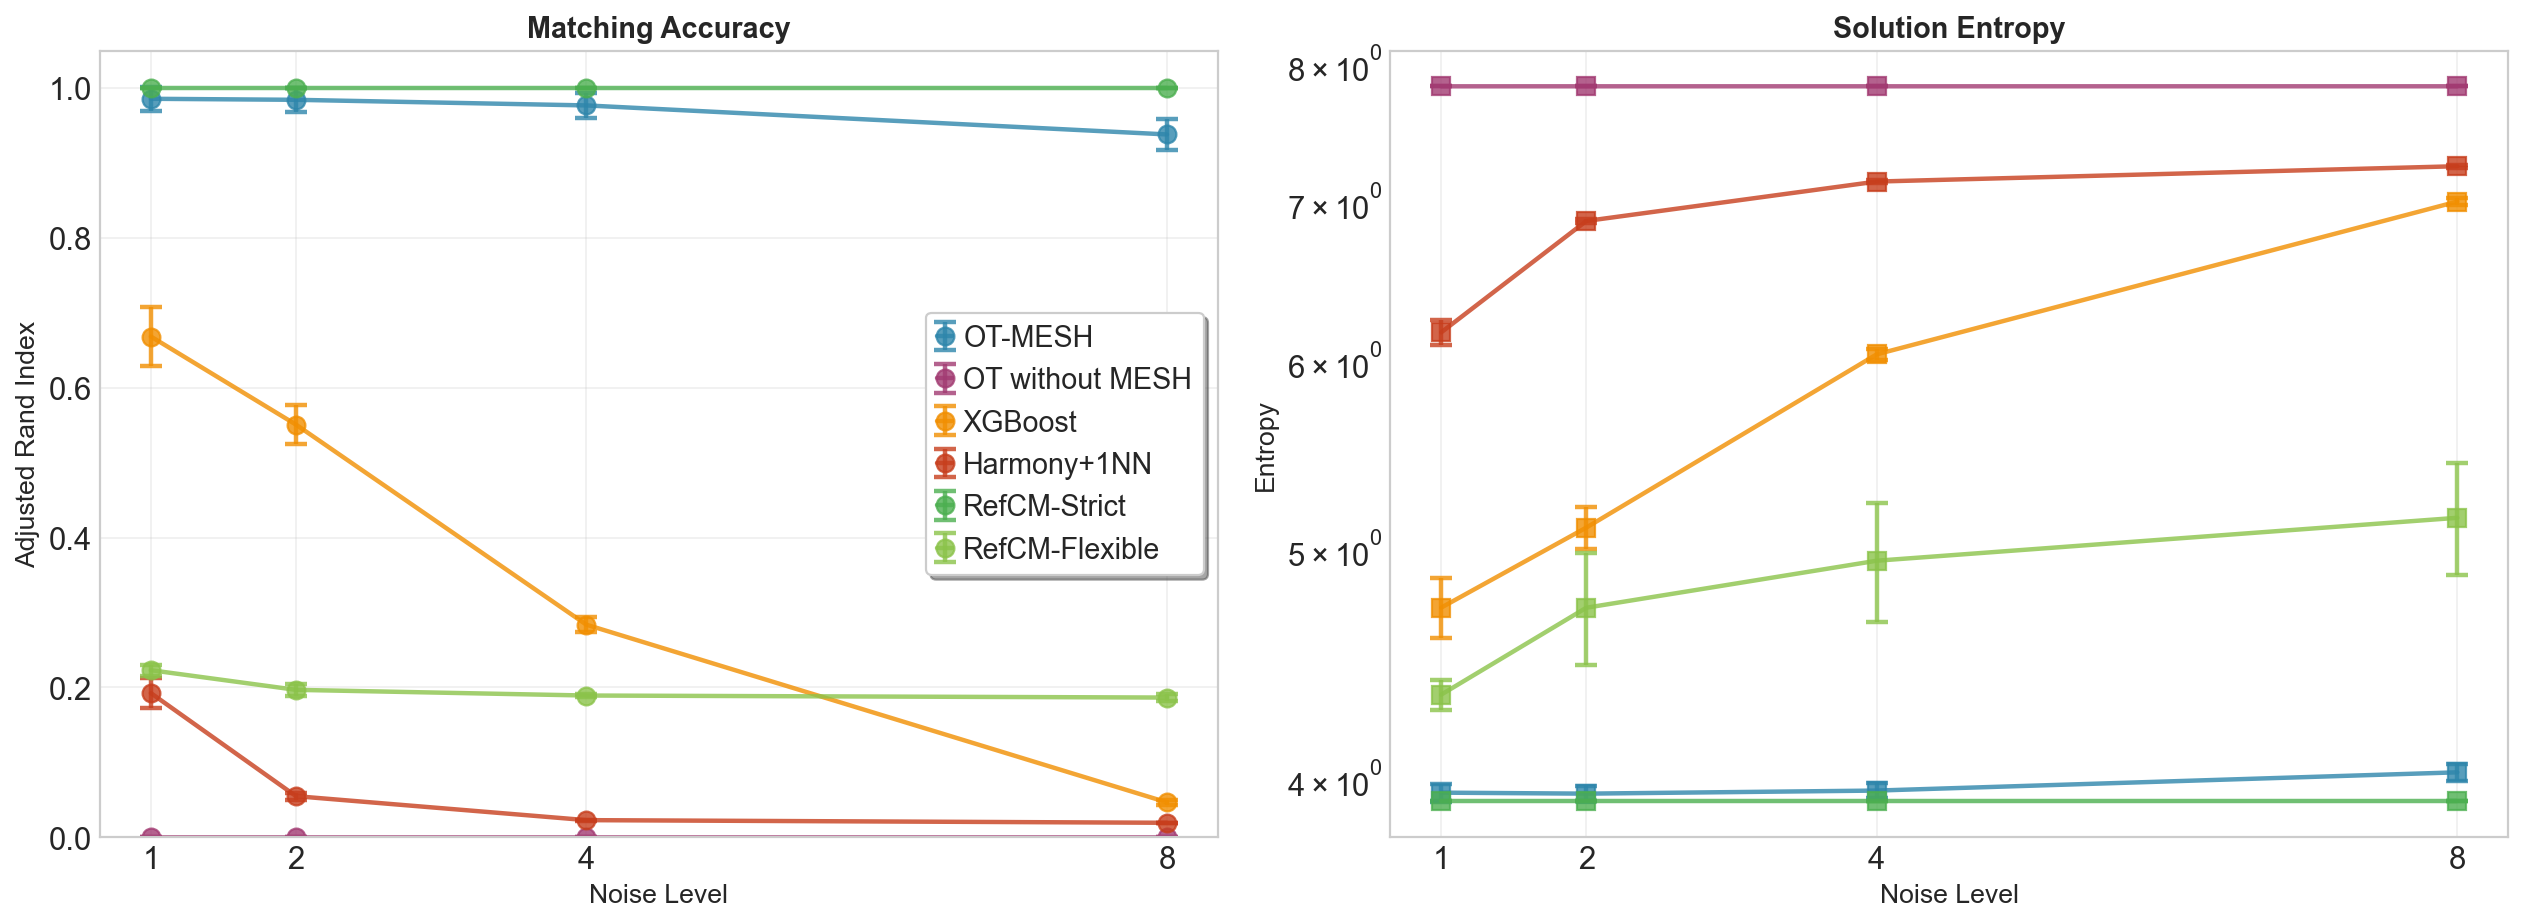


SUMMARY: ARI at Different Noise Levels
method       harmony  ot_mesh  ot_vanilla  refcm_flex  refcm_strict  xgboost
noise_level                                                                 
1.0            0.193    0.986        -0.0       0.223           1.0    0.668
2.0            0.055    0.984        -0.0       0.197           1.0    0.551
4.0            0.023    0.977        -0.0       0.189           1.0    0.284
8.0            0.019    0.938        -0.0       0.187           1.0    0.047

ROBUSTNESS SCORES (mean ARI across all noise levels)
refcm_strict  : 1.000
ot_mesh       : 0.971
xgboost       : 0.387
refcm_flex    : 0.199
harmony       : 0.072
ot_vanilla    : -0.000


In [4]:
print("="*60)
print("NOISE ROBUSTNESS BENCHMARK")
print("="*60)

# Load optimal parameters if available
try:
    with open("./Parameter_Selection/optimal_parameters.json", 'r') as f:
        optimal_params = json.load(f)
    optimal_params = {int(k): v for k, v in optimal_params.items()}
    print("Loaded optimal OT-MESH parameters")
except:
    print("Using default parameters")
    optimal_params = None

# Run benchmark
noise_levels = [1.0, 2.0, 4.0, 8.0]
results_df = benchmark_noise_robustness(
    n_types=50,
    n_cells_per_type=50,
    noise_levels=noise_levels,
    n_runs=3,
    optimal_params=optimal_params
)

# Save results
results_df.to_csv('./Noise_Robustness/noise_robustness_results.csv', index=False)
print("\nResults saved to noise_robustness_results.csv")

# Plot results
plot_noise_robustness(results_df)

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY: ARI at Different Noise Levels")
print("="*60)
pivot_table = results_df.pivot_table(
    values='ari_mean', 
    index='noise_level', 
    columns='method'
)
print(pivot_table.round(3))

# Calculate robustness score (average ARI across all noise levels)
print("\n" + "="*60)
print("ROBUSTNESS SCORES (mean ARI across all noise levels)")
print("="*60)
robustness = results_df.groupby('method')['ari_mean'].mean().sort_values(ascending=False)
for method, score in robustness.items():
    print(f"{method:14}: {score:.3f}")